# 第八章作业：线性自编码器完成手写数字分类

本 Notebook 参考《PyTorch 深度学习入门与实战》第 8 章自编码模型的思想，设计一个**基于线性层的自编码模型**，并使用编码得到的低维特征完成手写数字分类。

演示流程：

1. 读取 `sklearn` 自带的手写数字数据集，不需要联网下载。
2. 将 8×8 灰度图拉平成 64 维向量。
3. 搭建线性自编码器：`64 -> 48 -> 24 -> latent -> 24 -> 48 -> 64`。
4. 先训练自编码器完成图像重构，再加入分类头完成 0-9 数字识别。
5. 展示训练曲线、重构效果、分类报告、混淆矩阵和预测样例。

## 1. 导入依赖与基础配置

这里固定随机种子，保证多次运行时结果尽量稳定。程序会自动选择 CUDA 或 CPU。

In [2]:
from pathlib import Path
import copy
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

BATCH_SIZE = 128
LATENT_DIM = 12
AE_EPOCHS = 70
CLS_EPOCHS = 90
AE_LR = 1e-3
CLS_LR = 2e-3
RECON_WEIGHT = 0.20

print("PyTorch:", torch.__version__)
print("使用设备:", DEVICE)

PyTorch: 2.11.0+cu128
使用设备: cuda


## 2. 读取并划分手写数字数据

`load_digits()` 数据集一共有 1797 张 8×8 灰度手写数字图片，标签为 0 到 9。像素值范围是 0 到 16，这里统一缩放到 `[0, 1]`，方便自编码器使用 `Sigmoid` 输出重构图像。

In [3]:
digits = load_digits()
images = digits.images.astype(np.float32) / 16.0
labels = digits.target.astype(np.int64)

X_temp, X_test, y_temp, y_test = train_test_split(
    images,
    labels,
    test_size=0.15,
    random_state=SEED,
    stratify=labels,
)
val_ratio = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=val_ratio,
    random_state=SEED,
    stratify=y_temp,
)

def flatten_images(x):
    return x.reshape(len(x), -1).astype(np.float32)

X_train_flat = flatten_images(X_train)
X_val_flat = flatten_images(X_val)
X_test_flat = flatten_images(X_test)

print("训练集:", X_train_flat.shape, y_train.shape)
print("验证集:", X_val_flat.shape, y_val.shape)
print("测试集:", X_test_flat.shape, y_test.shape)

class_counts = pd.DataFrame(
    {
        "train": np.bincount(y_train, minlength=10),
        "val": np.bincount(y_val, minlength=10),
        "test": np.bincount(y_test, minlength=10),
    },
    index=[str(i) for i in range(10)],
)
class_counts

训练集: (1257, 64) (1257,)
验证集: (270, 64) (270,)
测试集: (270, 64) (270,)


,train,val,test
0,124,27,27
1,127,28,27
2,123,27,27
3,128,27,28
4,127,27,27
5,128,27,27
6,127,27,27
7,125,27,27
8,122,26,26
9,126,27,27


## 3. 观察部分数字样本

先看输入数据长什么样。每张图只有 8×8 个像素，因此模型输入是比较小的 64 维向量。

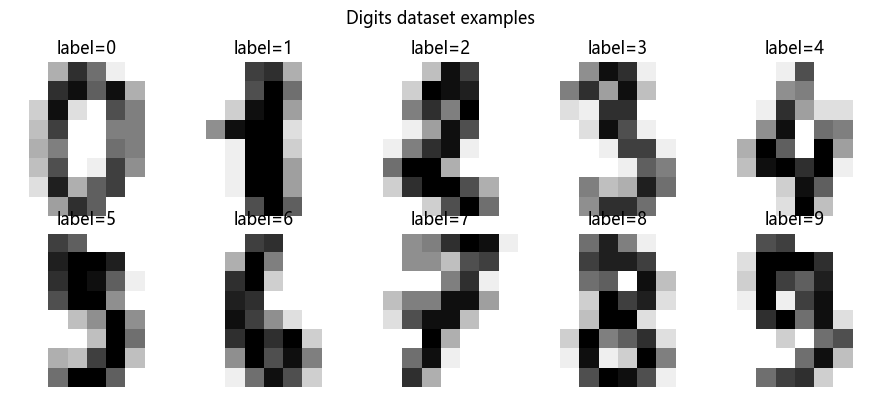

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for digit, ax in enumerate(axes.ravel()):
    idx = np.where(labels == digit)[0][0]
    ax.imshow(images[idx], cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(f"label={digit}")
    ax.axis("off")
plt.suptitle("Digits dataset examples")
plt.tight_layout()
plt.show()

## 4. 构建 PyTorch 数据加载器

图像被拉平成 64 维向量后，既可以作为自编码器的输入，也可以作为分类任务的输入。自编码器的目标是重构原图，分类器的目标是预测数字标签。

In [5]:
def make_dataset(x_flat, y):
    x_tensor = torch.tensor(x_flat, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)
    return TensorDataset(x_tensor, y_tensor)

train_dataset = make_dataset(X_train_flat, y_train)
val_dataset = make_dataset(X_val_flat, y_val)
test_dataset = make_dataset(X_test_flat, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print("一个 batch 的输入形状:", x_batch.shape)
print("一个 batch 的标签形状:", y_batch.shape)

一个 batch 的输入形状: torch.Size([128, 64])
一个 batch 的标签形状: torch.Size([128])


## 5. 定义线性自编码分类模型

模型由三部分组成：

- `encoder`：把 64 维图像压缩到 `latent_dim=12` 的低维表示。
- `decoder`：把低维表示还原回 64 维图像，用于学习有效特征。
- `classifier`：直接使用低维编码 `z` 输出 10 个类别的 logits。

主要参数层均为 `nn.Linear`，符合“基于线性层的自编码模型”的要求。

In [6]:
class LinearAutoEncoderClassifier(nn.Module):
    def __init__(self, input_dim=64, latent_dim=12, num_classes=10):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 48),
            nn.ReLU(),
            nn.Linear(48, 24),
            nn.ReLU(),
            nn.Linear(24, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 24),
            nn.ReLU(),
            nn.Linear(24, 48),
            nn.ReLU(),
            nn.Linear(48, input_dim),
            nn.Sigmoid(),
        )
        self.classifier = nn.Linear(latent_dim, num_classes)

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        logits = self.classifier(z)
        return reconstructed, logits, z


model = LinearAutoEncoderClassifier(latent_dim=LATENT_DIM).to(DEVICE)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")

LinearAutoEncoderClassifier(
  (encoder): Sequential(
    (0): Linear(in_features=64, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=12, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=24, bias=True)
    (1): ReLU()
    (2): Linear(in_features=24, out_features=48, bias=True)
    (3): ReLU()
    (4): Linear(in_features=48, out_features=64, bias=True)
    (5): Sigmoid()
  )
  (classifier): Linear(in_features=12, out_features=10, bias=True)
)
总参数量: 9,374
可训练参数量: 9,374


## 6. 第一阶段：训练自编码器完成图像重构

这一阶段只看重构误差。输入是一张数字图片，输出也应该尽量接近这张数字图片，因此损失函数使用均方误差 `MSELoss`。

In [7]:
def run_autoencoder_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_samples = 0

    for x, _ in loader:
        x = x.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        reconstructed, _, _ = model(x)
        loss = criterion(reconstructed, x)

        if is_train:
            loss.backward()
            optimizer.step()

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


def train_autoencoder(model, train_loader, val_loader, epochs=70, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(
        list(model.encoder.parameters()) + list(model.decoder.parameters()),
        lr=lr,
    )

    history = []
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss = run_autoencoder_epoch(model, train_loader, criterion, optimizer)
        with torch.no_grad():
            val_loss = run_autoencoder_epoch(model, val_loader, criterion)

        history.append(
            {
                "epoch": epoch,
                "train_recon_loss": train_loss,
                "val_recon_loss": val_loss,
            }
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(
                f"AE Epoch {epoch:03d}/{epochs} | "
                f"train_loss={train_loss:.5f} | val_loss={val_loss:.5f}"
            )

    model.load_state_dict(best_state)
    print(f"自编码器训练完成，用时 {time.time() - start_time:.1f} 秒，最佳验证重构误差 {best_val_loss:.5f}")
    return pd.DataFrame(history)


ae_history = train_autoencoder(model, train_loader, val_loader, AE_EPOCHS, AE_LR)
ae_history.tail()

AE Epoch 001/70 | train_loss=0.17833 | val_loss=0.17526
AE Epoch 010/70 | train_loss=0.07310 | val_loss=0.07411
AE Epoch 020/70 | train_loss=0.07183 | val_loss=0.07262
AE Epoch 030/70 | train_loss=0.05922 | val_loss=0.05967
AE Epoch 040/70 | train_loss=0.04935 | val_loss=0.04959
AE Epoch 050/70 | train_loss=0.04119 | val_loss=0.04084
AE Epoch 060/70 | train_loss=0.03725 | val_loss=0.03735
AE Epoch 070/70 | train_loss=0.03428 | val_loss=0.03430
自编码器训练完成，用时 6.6 秒，最佳验证重构误差 0.03430


,epoch,train_recon_loss,val_recon_loss
65,66,0.035675,0.035685
66,67,0.035398,0.035361
67,68,0.035069,0.034986
68,69,0.034768,0.034514
69,70,0.034281,0.034305


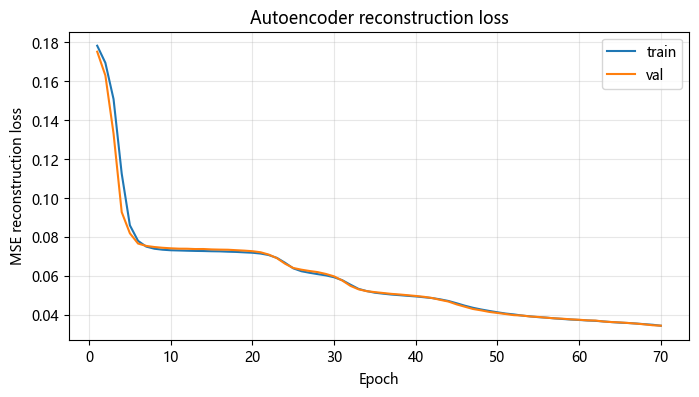

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(ae_history["epoch"], ae_history["train_recon_loss"], label="train")
plt.plot(ae_history["epoch"], ae_history["val_recon_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE reconstruction loss")
plt.title("Autoencoder reconstruction loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. 查看自编码器的重构效果

上面一行是原始测试图片，下面一行是自编码器重构出的图片。即使只压缩到 12 维，模型仍然能保留数字的大致形状。

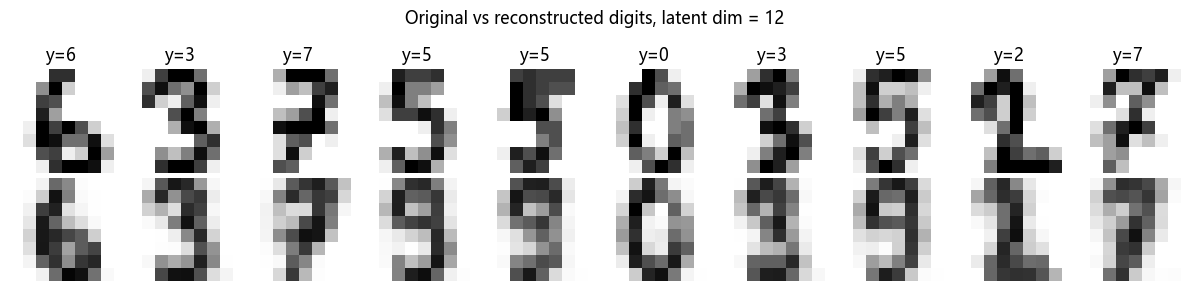

前 3 个样本的低维编码 z：


,0,1,2,3,4,5,6,7,8,9,10,11
0,6.866,3.904,-4.755,3.091,1.510,-4.059,1.070,-2.089,-4.655,-3.079,-5.025,2.948
1,5.337,6.679,-4.824,-0.908,-5.606,-4.814,3.471,-1.043,0.128,-5.957,-4.857,1.545
2,0.415,5.766,-0.721,-2.258,-1.178,-4.256,-0.555,-2.103,1.579,-6.244,-0.073,0.834


In [9]:
model.eval()
sample_x, sample_y = next(iter(test_loader))
sample_x = sample_x[:10].to(DEVICE)

with torch.no_grad():
    reconstructed, _, latent_z = model(sample_x)

original_np = sample_x.cpu().numpy().reshape(-1, 8, 8)
reconstructed_np = reconstructed.cpu().numpy().reshape(-1, 8, 8)

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axes[0, i].imshow(original_np[i], cmap="gray_r", vmin=0, vmax=1)
    axes[0, i].set_title(f"y={int(sample_y[i])}")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed_np[i], cmap="gray_r", vmin=0, vmax=1)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Recon")
plt.suptitle(f"Original vs reconstructed digits, latent dim = {LATENT_DIM}")
plt.tight_layout()
plt.show()

print("前 3 个样本的低维编码 z：")
pd.DataFrame(latent_z[:3].cpu().numpy()).round(3)

## 8. 第二阶段：加入分类损失进行数字识别

分类阶段使用两个损失：

- `CrossEntropyLoss`：让模型预测正确数字类别。
- `MSELoss`：继续保留自编码器的重构能力。

最终损失为：

`总损失 = 分类损失 + RECON_WEIGHT × 重构损失`

In [10]:
def evaluate_classifier(model, loader):
    model.eval()
    ce_loss_fn = nn.CrossEntropyLoss()
    mse_loss_fn = nn.MSELoss()

    total_loss = 0.0
    total_ce_loss = 0.0
    total_recon_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_true = []
    all_pred = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            reconstructed, logits, _ = model(x)

            ce_loss = ce_loss_fn(logits, y)
            recon_loss = mse_loss_fn(reconstructed, x)
            loss = ce_loss + RECON_WEIGHT * recon_loss

            pred = logits.argmax(dim=1)
            batch_size = x.size(0)

            total_loss += loss.item() * batch_size
            total_ce_loss += ce_loss.item() * batch_size
            total_recon_loss += recon_loss.item() * batch_size
            total_correct += (pred == y).sum().item()
            total_samples += batch_size
            all_true.extend(y.cpu().numpy().tolist())
            all_pred.extend(pred.cpu().numpy().tolist())

    return {
        "loss": total_loss / total_samples,
        "ce_loss": total_ce_loss / total_samples,
        "recon_loss": total_recon_loss / total_samples,
        "accuracy": total_correct / total_samples,
        "y_true": np.array(all_true),
        "y_pred": np.array(all_pred),
    }


def train_classifier(model, train_loader, val_loader, epochs=90, lr=2e-3):
    ce_loss_fn = nn.CrossEntropyLoss()
    mse_loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    history = []
    best_val_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_ce_loss = 0.0
        total_recon_loss = 0.0
        total_correct = 0
        total_samples = 0

        for x, y in train_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()
            reconstructed, logits, _ = model(x)
            ce_loss = ce_loss_fn(logits, y)
            recon_loss = mse_loss_fn(reconstructed, x)
            loss = ce_loss + RECON_WEIGHT * recon_loss
            loss.backward()
            optimizer.step()

            pred = logits.argmax(dim=1)
            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            total_ce_loss += ce_loss.item() * batch_size
            total_recon_loss += recon_loss.item() * batch_size
            total_correct += (pred == y).sum().item()
            total_samples += batch_size

        train_metrics = {
            "loss": total_loss / total_samples,
            "ce_loss": total_ce_loss / total_samples,
            "recon_loss": total_recon_loss / total_samples,
            "accuracy": total_correct / total_samples,
        }
        val_metrics = evaluate_classifier(model, val_loader)

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "train_ce_loss": train_metrics["ce_loss"],
                "train_recon_loss": train_metrics["recon_loss"],
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_ce_loss": val_metrics["ce_loss"],
                "val_recon_loss": val_metrics["recon_loss"],
            }
        )

        if val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            best_state = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(
                f"CLS Epoch {epoch:03d}/{epochs} | "
                f"train_acc={train_metrics['accuracy']:.4f} | "
                f"val_acc={val_metrics['accuracy']:.4f} | "
                f"val_loss={val_metrics['loss']:.4f}"
            )

    model.load_state_dict(best_state)
    print(f"分类训练完成，用时 {time.time() - start_time:.1f} 秒，最佳验证准确率 {best_val_acc:.4f}")
    return pd.DataFrame(history)


cls_history = train_classifier(model, train_loader, val_loader, CLS_EPOCHS, CLS_LR)
cls_history.tail()

CLS Epoch 001/90 | train_acc=0.2013 | val_acc=0.3222 | val_loss=2.1011
CLS Epoch 010/90 | train_acc=0.8218 | val_acc=0.8148 | val_loss=0.6799
CLS Epoch 020/90 | train_acc=0.9260 | val_acc=0.8741 | val_loss=0.3394
CLS Epoch 030/90 | train_acc=0.9658 | val_acc=0.9296 | val_loss=0.2248
CLS Epoch 040/90 | train_acc=0.9793 | val_acc=0.9481 | val_loss=0.1858
CLS Epoch 050/90 | train_acc=0.9897 | val_acc=0.9519 | val_loss=0.1792
CLS Epoch 060/90 | train_acc=0.9936 | val_acc=0.9556 | val_loss=0.1585
CLS Epoch 070/90 | train_acc=0.9968 | val_acc=0.9481 | val_loss=0.1586
CLS Epoch 080/90 | train_acc=0.9976 | val_acc=0.9556 | val_loss=0.1606
CLS Epoch 090/90 | train_acc=0.9992 | val_acc=0.9593 | val_loss=0.1480
分类训练完成，用时 8.7 秒，最佳验证准确率 0.9630


,epoch,train_loss,train_accuracy,train_ce_loss,train_recon_loss,val_loss,val_accuracy,val_ce_loss,val_recon_loss
85,86,0.022785,0.999204,0.017321,0.027324,0.150230,0.955556,0.144710,0.027601
86,87,0.022897,0.999204,0.017438,0.027295,0.145422,0.959259,0.139860,0.027810
87,88,0.021718,0.998409,0.016265,0.027267,0.152853,0.959259,0.147325,0.027636
88,89,0.021408,0.999204,0.015972,0.027182,0.151299,0.959259,0.145768,0.027653
89,90,0.020174,0.999204,0.014736,0.027193,0.148033,0.959259,0.142533,0.027497


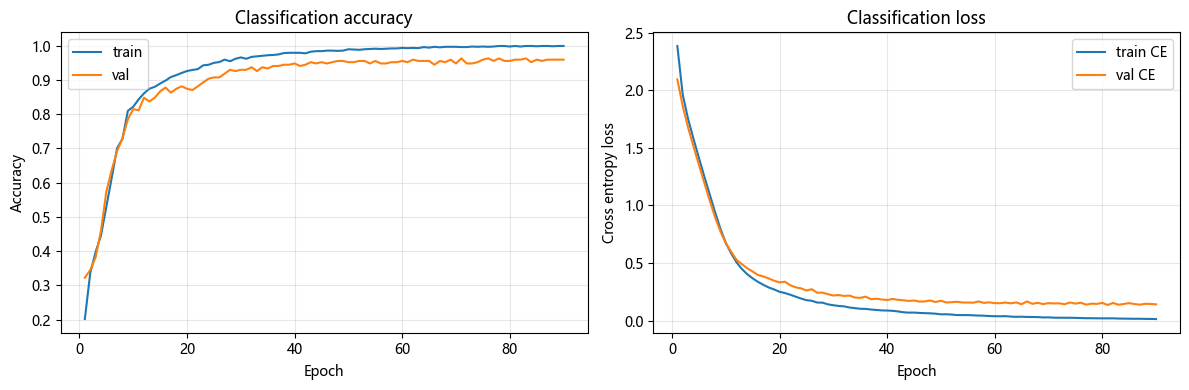

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cls_history["epoch"], cls_history["train_accuracy"], label="train")
axes[0].plot(cls_history["epoch"], cls_history["val_accuracy"], label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Classification accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(cls_history["epoch"], cls_history["train_ce_loss"], label="train CE")
axes[1].plot(cls_history["epoch"], cls_history["val_ce_loss"], label="val CE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cross entropy loss")
axes[1].set_title("Classification loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. 在测试集上评估模型

测试集不参与训练和调参，因此它更能反映模型对新样本的识别能力。

In [12]:
test_metrics = evaluate_classifier(model, test_loader)
print(f"测试集准确率: {test_metrics['accuracy']:.4f}")
print(f"测试集分类损失: {test_metrics['ce_loss']:.4f}")
print(f"测试集重构误差: {test_metrics['recon_loss']:.5f}")

report = classification_report(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    labels=list(range(10)),
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).T
report_df.round(4)

测试集准确率: 0.9519
测试集分类损失: 0.1165
测试集重构误差: 0.02856


,precision,recall,f1-score,support
0,1.0000,1.0000,1.0000,27.0000
1,0.8000,0.8889,0.8421,27.0000
2,0.9643,1.0000,0.9818,27.0000
3,1.0000,0.9643,0.9818,28.0000
4,1.0000,0.9259,0.9615,27.0000
5,1.0000,1.0000,1.0000,27.0000
6,0.9310,1.0000,0.9643,27.0000
7,0.9643,1.0000,0.9818,27.0000
8,0.9130,0.8077,0.8571,26.0000
9,0.9615,0.9259,0.9434,27.0000


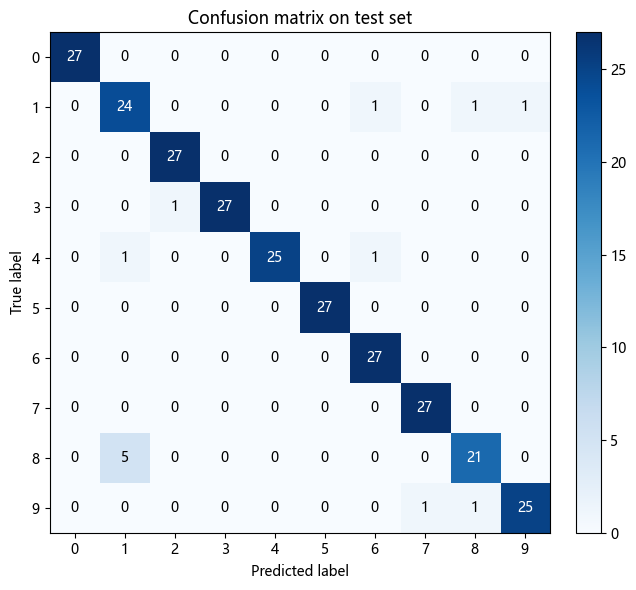

In [13]:
cm = confusion_matrix(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    labels=list(range(10)),
)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion matrix on test set")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(10))
ax.set_yticks(range(10))

for i in range(10):
    for j in range(10):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() * 0.55 else "black",
        )

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 10. 展示预测样例

绿色标题表示预测正确，红色标题表示预测错误。形状相似的数字更容易被混淆。

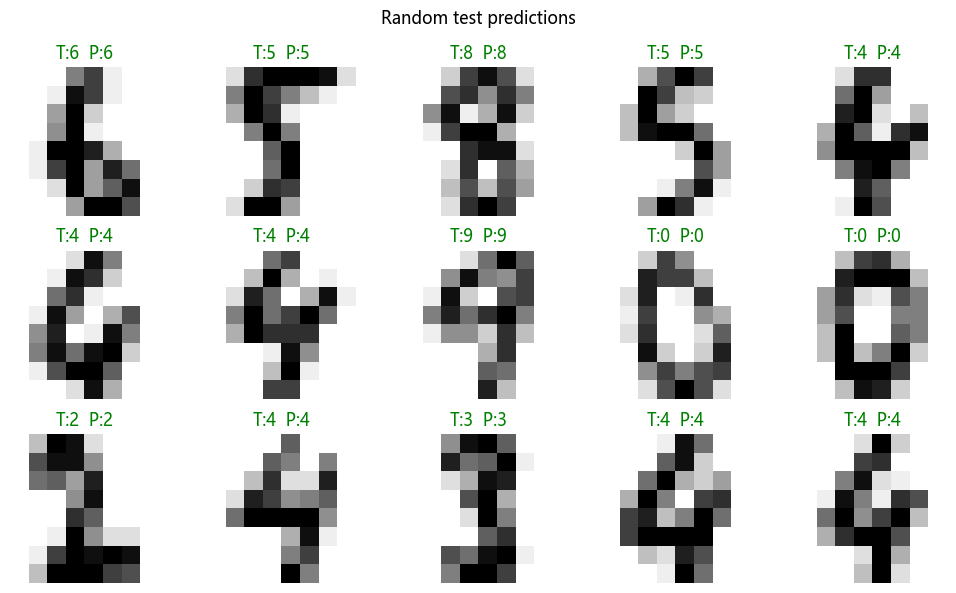

In [14]:
model.eval()
x_test_tensor = torch.tensor(X_test_flat, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    _, logits, _ = model(x_test_tensor)
    all_pred = logits.argmax(dim=1).cpu().numpy()

rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(X_test), size=15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for ax, idx in zip(axes.ravel(), sample_indices):
    true_label = int(y_test[idx])
    pred_label = int(all_pred[idx])
    color = "green" if true_label == pred_label else "red"
    ax.imshow(X_test[idx], cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(f"T:{true_label}  P:{pred_label}", color=color)
    ax.axis("off")

plt.suptitle("Random test predictions")
plt.tight_layout()
plt.show()

## 11. 保存模型与结论

本实验说明：线性自编码器可以先把手写数字图片压缩成低维特征，再基于这个低维特征完成分类。虽然数据集图片很小，但这个流程体现了自编码模型“编码-解码-利用编码特征”的基本思想。

In [15]:
artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)

model_path = artifact_dir / "linear_autoencoder_digits.pt"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "latent_dim": LATENT_DIM,
        "test_accuracy": float(test_metrics["accuracy"]),
        "seed": SEED,
    },
    model_path,
)

print(f"模型已保存到: {model_path.resolve()}")
print(f"最终测试集准确率: {test_metrics['accuracy']:.2%}")
print("模型用线性层完成编码、重构和分类，测试集准确率达到较高水平。")

模型已保存到: D:\steven\hw\rgzn\hw8\artifacts\linear_autoencoder_digits.pt
最终测试集准确率: 95.19%
模型用线性层完成编码、重构和分类，测试集准确率达到较高水平。
